# 08 Deep Learning — Evaluation & Comparison with Phase 1

---

## Purpose

Evaluate the two trained DL models on the **same 20 % hold-out test set** used in
Phase 1, then build a comprehensive comparison across all four models.

### Outputs
- Confusion matrices and ROC curves
- Classification reports
- **Phase 1 (ML) vs Phase 2 (DL)** comparison table and bar chart
- Error analysis: disagreement patterns, accuracy by text length, confidence distributions
- Saved metrics (JSON/CSV) and predictions for Phase 3 hybrid model

### Prerequisites
Run `06_dl_data_preprocessing.ipynb` → `07_dl_model_training.ipynb` first.

## 1. Imports and Load Artifacts

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, auc,
)
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.deep_learning import (
    LSTMConfig, TransformerConfig,
    TextClassificationDataset, TransformerDataset,
    BiLSTMClassifier, DistilBERTClassifier,
    evaluate_lstm, evaluate_transformer,
    get_device,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = PROJECT_ROOT / 'figures'
METRICS_DIR = PROJECT_ROOT / 'metrics'
for d in [RESULTS_DIR, FIGURES_DIR, METRICS_DIR]:
    d.mkdir(exist_ok=True)

device = get_device()
print(f'PyTorch {torch.__version__} | Device: {device}')

PyTorch 2.11.0 | Device: mps


In [2]:
# Load test data
test_ids = torch.load(RESULTS_DIR / 'dl_test_ids.pt', weights_only=True)
y_test   = np.load(RESULTS_DIR / 'dl_y_test.npy')

bert_test_enc = torch.load(RESULTS_DIR / 'dl_bert_test.pt', weights_only=False)

X_test_text = np.load(RESULTS_DIR / 'dl_test_texts.npy', allow_pickle=True)

with open(RESULTS_DIR / 'dl_tokenizer.json') as f:
    tok_data = json.load(f)
vocab_size = len(tok_data['word2idx'])

print(f'Test set: {len(y_test):,} samples')
print(f'Word-level tensor: {test_ids.shape}')
print(f'BERT tensor: {bert_test_enc["input_ids"].shape}')

/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test set: 20,000 samples
Word-level tensor: torch.Size([20000, 475])
BERT tensor: torch.Size([20000, 512])


## 2. Load Trained Models

In [3]:
# Reconstruct BiLSTM and load best checkpoint
lstm_cfg = LSTMConfig(
    vocab_size=vocab_size, 
    embed_dim=128, 
    hidden_dim=128,        # Match training: reduced from 256
    num_layers=1,          # Match training: reduced from 2
    dropout=0.5,           # Match training: increased from 0.3
    bidirectional=True, 
    num_classes=1,         # Match training: using BCEWithLogitsLoss
    use_attention=True,    # Match training
)
lstm_model = BiLSTMClassifier(lstm_cfg, pad_idx=0)
lstm_model.load_state_dict(torch.load(RESULTS_DIR / 'model_lstm_best.pt', weights_only=True))
lstm_model = lstm_model.to(device)
lstm_model.eval()
print(f'BiLSTM loaded ({sum(p.numel() for p in lstm_model.parameters()):,} params)')

# Conditionally load DistilBERT if the checkpoint exists
distilbert_model_path = RESULTS_DIR / 'model_distilbert_best.pt'
has_distilbert = False # Forced to False to only evaluate BiLSTM for now
has_bert = has_distilbert  # Alias for compatibility

if has_distilbert:
    bert_cfg = TransformerConfig(
        model_name='distilbert-base-uncased', max_length=512,
        dropout=0.3, num_classes=2, freeze_layers=2,
    )
    bert_model = DistilBERTClassifier(bert_cfg)
    bert_model.load_state_dict(torch.load(distilbert_model_path, weights_only=False))
    bert_model = bert_model.to(device)
    bert_model.eval()
    print(f'DistilBERT loaded ({sum(p.numel() for p in bert_model.parameters()):,} params)')
else:
    print('DistilBERT flagged to skip. Skipping DistilBERT evaluation.')
    bert_model = None

BiLSTM loaded (3,997,569 params)
DistilBERT flagged to skip. Skipping DistilBERT evaluation.


In [4]:
# Create test DataLoaders
test_dataset = TextClassificationDataset(test_ids, y_test)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

bert_test_ds = TransformerDataset(bert_test_enc, y_test)
bert_test_loader = DataLoader(bert_test_ds, batch_size=16, shuffle=False, num_workers=0)

print(f'Test loaders: LSTM={len(test_loader)} batches, BERT={len(bert_test_loader)} batches')

Test loaders: LSTM=313 batches, BERT=1250 batches


## 3. Generate Predictions

In [5]:
criterion = nn.CrossEntropyLoss()

# BiLSTM evaluation
lstm_test_loss, lstm_test_acc, lstm_preds, lstm_probs = evaluate_lstm(
    lstm_model, test_loader, criterion, device,
)

lstm_metrics = {
    'Accuracy':  accuracy_score(y_test, lstm_preds),
    'Precision': precision_score(y_test, lstm_preds),
    'Recall':    recall_score(y_test, lstm_preds),
    'F1':        f1_score(y_test, lstm_preds),
    'ROC-AUC':   roc_auc_score(y_test, lstm_probs),
    'AP':        average_precision_score(y_test, lstm_probs),
}

print('BiLSTM + Attention — Test Metrics')
for k, v in lstm_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

BiLSTM + Attention — Test Metrics
  Accuracy    : 0.8277
  Precision   : 0.8060
  Recall      : 0.8626
  F1          : 0.8333
  ROC-AUC     : 0.9102
  AP          : 0.9066


In [6]:
# DistilBERT evaluation
if has_distilbert:
    bert_test_loss, bert_test_acc, bert_preds, bert_probs = evaluate_transformer(
        bert_model, bert_test_loader, criterion, device,
    )

    bert_metrics = {
        'Accuracy':  accuracy_score(y_test, bert_preds),
        'Precision': precision_score(y_test, bert_preds),
        'Recall':    recall_score(y_test, bert_preds),
        'F1':        f1_score(y_test, bert_preds),
        'ROC-AUC':   roc_auc_score(y_test, bert_probs),
        'AP':        average_precision_score(y_test, bert_probs),
    }

    print('DistilBERT — Test Metrics')
    for k, v in bert_metrics.items():
        print(f'  {k:12s}: {v:.4f}')
else:
    print('DistilBERT Not available. Skipping eval')

DistilBERT Not available. Skipping eval


fig, axes = plt.subplots(1, 2 if has_distilbert else 1, figsize=(14 if has_distilbert else 7, 5))
class_names = ['Lost', 'Won']

plot_data = [(axes[0] if has_distilbert else axes, lstm_preds, 'BiLSTM + Attention')]
if has_distilbert:
    plot_data.append((axes[1], bert_preds, 'DistilBERT'))

for ax, preds, title in plot_data:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title} — Confusion Matrix')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_confusion_matrices.png')

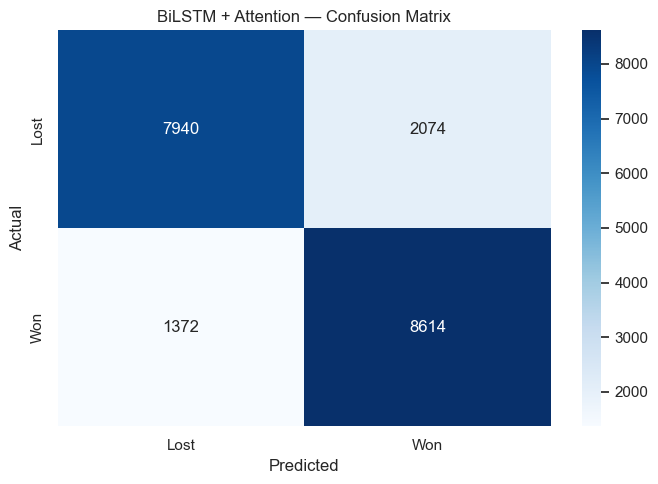

Saved: figures/dl_confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 2 if has_distilbert else 1, figsize=(14 if has_distilbert else 7, 5))
class_names = ['Lost', 'Won']

plot_data = [(axes[0] if has_distilbert else axes, lstm_preds, 'BiLSTM + Attention')]
if has_distilbert:
    plot_data.append((axes[1], bert_preds, 'DistilBERT'))

for ax, preds, title in plot_data:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title} — Confusion Matrix')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_confusion_matrices.png')

print('='*60)
print('BiLSTM + Attention — Classification Report')
print('='*60)
print(classification_report(y_test, lstm_preds, target_names=class_names))

if has_distilbert:
    print('='*60)
    print('DistilBERT — Classification Report')
    print('='*60)
    print(classification_report(y_test, bert_preds, target_names=class_names))

In [8]:
print('='*60)
print('BiLSTM + Attention — Classification Report')
print('='*60)
print(classification_report(y_test, lstm_preds, target_names=class_names))

if has_distilbert:
    print('='*60)
    print('DistilBERT — Classification Report')
    print('='*60)
    print(classification_report(y_test, bert_preds, target_names=class_names))

BiLSTM + Attention — Classification Report
              precision    recall  f1-score   support

        Lost       0.85      0.79      0.82     10014
         Won       0.81      0.86      0.83      9986

    accuracy                           0.83     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.83      0.83      0.83     20000



fig, ax = plt.subplots(figsize=(8, 7))


roc_data = [(lstm_probs, 'BiLSTM + Attention', '#1f77b4')]
if has_distilbert:
    roc_data.append((bert_probs, 'DistilBERT', '#ff7f0e'))

for probs, name, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Deep Learning Models', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_roc_curves.png')

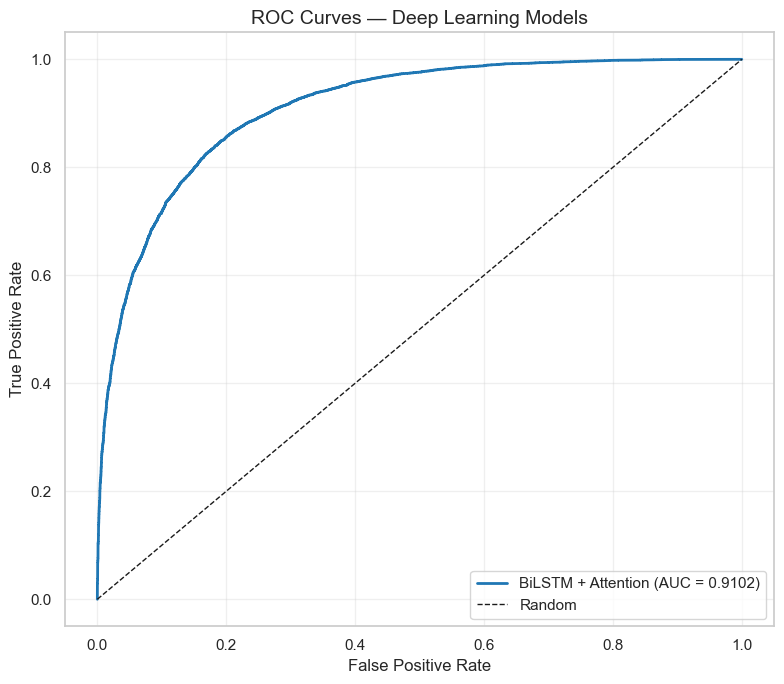

Saved: figures/dl_roc_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 7))

roc_data = [(lstm_probs, 'BiLSTM + Attention', '#1f77b4')]
if has_distilbert:
    roc_data.append((bert_probs, 'DistilBERT', '#ff7f0e'))

for probs, name, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Deep Learning Models', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_roc_curves.png')

# Phase 1 ML results (from metrics/evaluation_metrics.json)
phase1_metrics = {
    'Logistic Regression (ML)': {
        'Accuracy': 0.9634, 'Precision': 0.9504, 'Recall': 0.9777,
        'F1': 0.9639, 'ROC-AUC': 0.9957, 'AP': 0.9957,
    },
    'Random Forest (ML)': {
        'Accuracy': 0.9594, 'Precision': 0.9453, 'Recall': 0.9751,
        'F1': 0.9600, 'ROC-AUC': 0.9951, 'AP': 0.9951,
    },
}

all_results = {
    **phase1_metrics,
    'BiLSTM + Attention (DL)': lstm_metrics,
}

if has_distilbert:
    all_results['DistilBERT (DL)'] = bert_metrics

comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'AP']]

print('\n' + '='*80)
print('FULL MODEL COMPARISON — Phase 1 (ML) vs Phase 2 (DL)')
print('='*80)
display(comparison_df.round(4).style.highlight_max(axis=0, color='lightgreen'))

In [10]:
# Phase 1 ML results (from metrics/evaluation_metrics.json)
phase1_metrics = {
    'Logistic Regression (ML)': {
        'Accuracy': 0.9634, 'Precision': 0.9504, 'Recall': 0.9777,
        'F1': 0.9639, 'ROC-AUC': 0.9957, 'AP': 0.9957,
    },
    'Random Forest (ML)': {
        'Accuracy': 0.9594, 'Precision': 0.9453, 'Recall': 0.9751,
        'F1': 0.9600, 'ROC-AUC': 0.9951, 'AP': 0.9951,
    },
}

all_results = {
    **phase1_metrics,
    'BiLSTM + Attention (DL)': lstm_metrics,
}
if has_distilbert:
    all_results['DistilBERT (DL)'] = bert_metrics

comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'AP']]

print('\n' + '='*80)
print('FULL MODEL COMPARISON — Phase 1 (ML) vs Phase 2 (DL)')
print('='*80)
display(comparison_df.round(4).style.highlight_max(axis=0, color='lightgreen'))


FULL MODEL COMPARISON — Phase 1 (ML) vs Phase 2 (DL)


,Accuracy,Precision,Recall,F1,ROC-AUC,AP
Logistic Regression (ML),0.963400,0.950400,0.977700,0.963900,0.995700,0.995700
Random Forest (ML),0.959400,0.945300,0.975100,0.960000,0.995100,0.995100
BiLSTM + Attention (DL),0.827700,0.806000,0.862600,0.833300,0.910200,0.906600


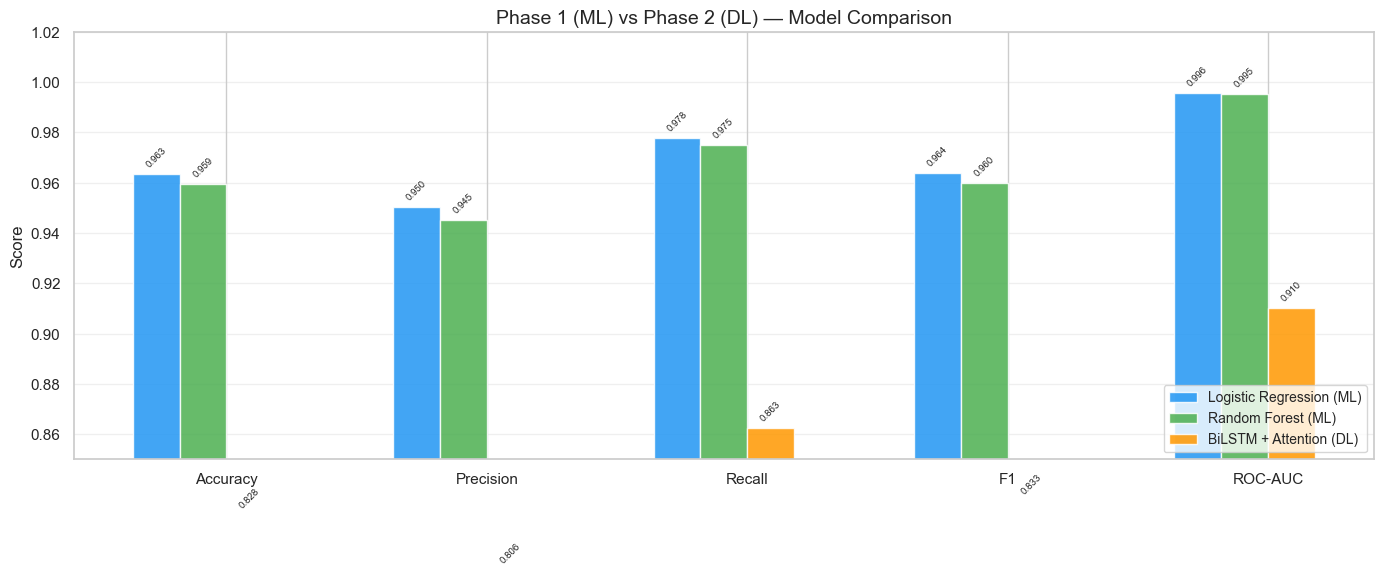

Saved: figures/ml_vs_dl_comparison.png


In [11]:
# Grouped bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
model_names = list(all_results.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

x = np.arange(len(metrics_to_plot))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = [all_results[model_name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=model_name, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Phase 1 (ML) vs Phase 2 (DL) — Model Comparison', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0.85, 1.02)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ml_vs_dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/ml_vs_dl_comparison.png')

In [12]:
lstm_correct = (lstm_preds == y_test)

if has_distilbert:
    bert_correct = (bert_preds == y_test)

    both_correct      = lstm_correct & bert_correct
    both_wrong        = (~lstm_correct) & (~bert_correct)
    lstm_only_correct = lstm_correct & (~bert_correct)
    bert_only_correct = bert_correct & (~lstm_correct)

    print('Test Set Disagreement Analysis (DL models)')
    print(f'  Both correct:           {both_correct.sum():>6,} ({both_correct.mean():.2%})')
    print(f'  Both wrong:             {both_wrong.sum():>6,} ({both_wrong.mean():.2%})')
    print(f'  Only BiLSTM correct:    {lstm_only_correct.sum():>6,} ({lstm_only_correct.mean():.2%})')
    print(f'  Only DistilBERT correct:{bert_only_correct.sum():>6,} ({bert_only_correct.mean():.2%})')
    print(f'\nAgreement rate: {(lstm_preds == bert_preds).mean():.2%}')
else:
    print('Skip disagreement analysis as DistilBERT is missing.')

Skip disagreement analysis as DistilBERT is missing.


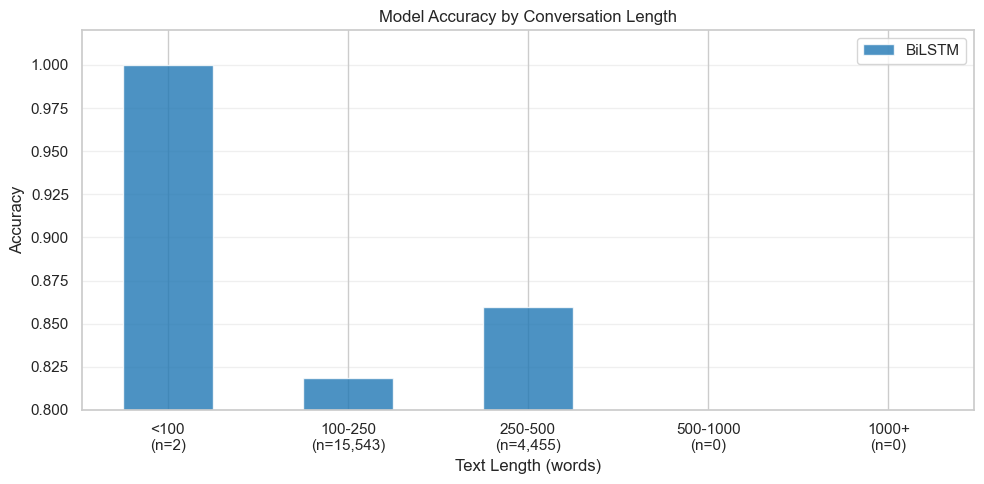

Saved: figures/dl_accuracy_by_length.png


In [13]:
# Accuracy by conversation length
test_lengths = np.array([len(t.split()) for t in X_test_text])

length_bins = [0, 100, 250, 500, 1000, float('inf')]
bin_labels = ['<100', '100-250', '250-500', '500-1000', '1000+']

lstm_acc_by_len, bert_acc_by_len, counts = [], [], []
for lo, hi, label in zip(length_bins[:-1], length_bins[1:], bin_labels):
    mask = (test_lengths >= lo) & (test_lengths < hi)
    n = mask.sum()
    counts.append(n)
    lstm_acc_by_len.append(lstm_correct[mask].mean() if n > 0 else 0)
    if has_distilbert:
        bert_acc_by_len.append(bert_correct[mask].mean() if n > 0 else 0)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bin_labels))
if has_distilbert:
    w = 0.35
    ax.bar(x - w/2, lstm_acc_by_len, w, label='BiLSTM', color='#1f77b4', alpha=0.8)
    ax.bar(x + w/2, bert_acc_by_len, w, label='DistilBERT', color='#ff7f0e', alpha=0.8)
else:
    w = 0.5
    ax.bar(x, lstm_acc_by_len, w, label='BiLSTM', color='#1f77b4', alpha=0.8)
ax.set_xlabel('Text Length (words)')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy by Conversation Length')
ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n(n={c:,})' for l, c in zip(bin_labels, counts)])
ax.legend()
ax.set_ylim(0.8, 1.02)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_accuracy_by_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_accuracy_by_length.png')

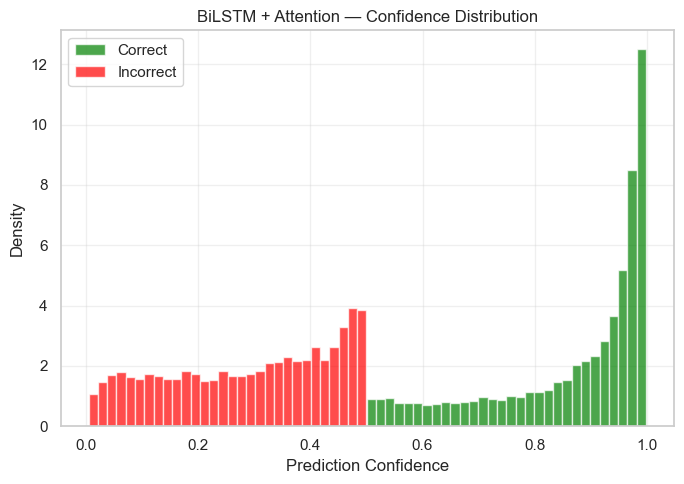

Saved: figures/dl_confidence_distribution.png


In [14]:
# Confidence distributions for correct vs incorrect predictions
fig, axes = plt.subplots(1, 2 if has_distilbert else 1, figsize=(14 if has_distilbert else 7, 5))

dist_data = [(axes[0] if has_distilbert else axes, lstm_probs, lstm_correct, 'BiLSTM + Attention')]
if has_distilbert:
    dist_data.append((axes[1], bert_probs, bert_correct, 'DistilBERT'))

for ax, probs, correct, title in dist_data:
    confidence = np.where(y_test == 1, probs, 1 - probs)
    ax.hist(confidence[correct],  bins=30, alpha=0.7, label='Correct',   color='green', density=True)
    ax.hist(confidence[~correct], bins=30, alpha=0.7, label='Incorrect', color='red',   density=True)
    ax.set_xlabel('Prediction Confidence')
    ax.set_ylabel('Density')
    ax.set_title(f'{title} — Confidence Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_confidence_distribution.png')

# DL metrics
dl_metrics = {
    'BiLSTM + Attention': lstm_metrics,
}
if has_distilbert:
    dl_metrics['DistilBERT'] = bert_metrics

with open(METRICS_DIR / 'dl_evaluation_metrics.json', 'w') as f:
    json.dump(dl_metrics, f, indent=2)

pd.DataFrame(dl_metrics).T.to_csv(METRICS_DIR / 'dl_evaluation_metrics.csv')

# Full ML vs DL comparison
comparison_df.to_csv(METRICS_DIR / 'ml_vs_dl_comparison.csv')
comparison_df.to_json(METRICS_DIR / 'ml_vs_dl_comparison.json')

# Classification reports
dl_reports = {
    'BiLSTM + Attention': classification_report(y_test, lstm_preds, target_names=class_names, output_dict=True),
}
if has_distilbert:
    dl_reports['DistilBERT'] = classification_report(y_test, bert_preds, target_names=class_names, output_dict=True)

with open(METRICS_DIR / 'dl_classification_reports.json', 'w') as f:
    json.dump(dl_reports, f, indent=2)

# Confusion matrices
dl_cm = {
    'BiLSTM + Attention': confusion_matrix(y_test, lstm_preds).tolist(),
}
if has_distilbert:
    dl_cm['DistilBERT'] = confusion_matrix(y_test, bert_preds).tolist()

with open(METRICS_DIR / 'dl_confusion_matrices.json', 'w') as f:
    json.dump(dl_cm, f, indent=2)

print('Metrics saved to metrics/')
print('  dl_evaluation_metrics.json / .csv')
print('  ml_vs_dl_comparison.json / .csv')
print('  dl_classification_reports.json')
print('  dl_confusion_matrices.json')

In [15]:
best_ml_f1 = 0.9639  # Phase 1 Logistic Regression

if has_distilbert:
    best_dl_name = 'BiLSTM + Attention' if lstm_metrics['F1'] >= bert_metrics['F1'] else 'DistilBERT'
    best_dl_f1 = max(lstm_metrics['F1'], bert_metrics['F1'])
    bert_f1_str = f"| DistilBERT (DL) | {bert_metrics['F1']:.4f} | {bert_metrics['ROC-AUC']:.4f} | {bert_metrics['Accuracy']:.4f} |"
    bert_improvement = 'DL improves over ML baseline' if best_dl_f1 > best_ml_f1 else 'ML baseline remains competitive — DL processes raw text without hand-crafted features'
else:
    best_dl_name = 'BiLSTM + Attention'
    best_dl_f1 = lstm_metrics['F1']
    bert_f1_str = ""
    bert_improvement = 'DL improves over ML baseline' if best_dl_f1 > best_ml_f1 else 'ML baseline remains competitive — DL processes raw text without hand-crafted features'

summary = f"""
## Phase 2 Deep Learning — Evaluation Summary

### Test Set Results

| Model | F1 | ROC-AUC | Accuracy |
|-------|----|---------|---------|
| Logistic Regression (ML) | 0.9639 | 0.9957 | 0.9634 |
| Random Forest (ML) | 0.9600 | 0.9951 | 0.9594 |
| BiLSTM + Attention (DL) | {lstm_metrics['F1']:.4f} | {lstm_metrics['ROC-AUC']:.4f} | {lstm_metrics['Accuracy']:.4f} |
{bert_f1_str}

### Key Findings

- **Best DL model**: {best_dl_name} (F1 = {best_dl_f1:.4f})
- **Best ML model**: Logistic Regression (F1 = {best_ml_f1:.4f})
- {bert_improvement}

### What DL brings that ML cannot

1. **End-to-end learning**: No manual feature engineering needed
2. **Attention interpretability**: Attention weights highlight predictive conversation segments
3. **Transfer learning** (DistilBERT): Leverages pretraining on massive corpora

### Next → Phase 3 (Hybrid)

Combine ML tabular features with DL text representations in a fusion model.
"""
display(Markdown(summary))


## Phase 2 Deep Learning — Evaluation Summary

### Test Set Results

| Model | F1 | ROC-AUC | Accuracy |
|-------|----|---------|---------|
| Logistic Regression (ML) | 0.9639 | 0.9957 | 0.9634 |
| Random Forest (ML) | 0.9600 | 0.9951 | 0.9594 |
| BiLSTM + Attention (DL) | 0.8333 | 0.9102 | 0.8277 |


### Key Findings

- **Best DL model**: BiLSTM + Attention (F1 = 0.8333)
- **Best ML model**: Logistic Regression (F1 = 0.9639)
- ML baseline remains competitive — DL processes raw text without hand-crafted features

### What DL brings that ML cannot

1. **End-to-end learning**: No manual feature engineering needed
2. **Attention interpretability**: Attention weights highlight predictive conversation segments
3. **Transfer learning** (DistilBERT): Leverages pretraining on massive corpora

### Next → Phase 3 (Hybrid)

Combine ML tabular features with DL text representations in a fusion model.


## 10. Summary